## Pre Model Checks

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from pathlib import Path
import sys
sys.path.append("../src")
from data_loader import load_data

In [3]:
data = load_data()

train = data["train"]["listings"].copy()
val = data["val"]["listings"].copy()
test = data["test"]["listings"].copy()

train_reviews = data["train"]["reviews"].copy()
val_reviews = data["val"]["reviews"].copy()
test_reviews = data["test"]["reviews"].copy()

print("Listings:")
print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

print("\nReviews:")
print("Train:", train_reviews.shape)
print("Validation:", val_reviews.shape)
print("Test:", test_reviews.shape)

Listings:
Train: (5868, 41)
Validation: (1483, 41)
Test: (1853, 41)

Reviews:
Train: (349702, 3)
Validation: (93585, 3)
Test: (112090, 3)


In [4]:
for split_name, split_df in {
    "train": train,
    "val": val,
    "test": test
}.items():
    total_rows = len(split_df)
    unique_ids = split_df["listing_id"].nunique()
    duplicated_ids = split_df["listing_id"].duplicated().sum()

    print(f"{split_name}:")
    print(f"  rows: {total_rows}")
    print(f"  unique listing IDs: {unique_ids}")
    print(f"  duplicated listing IDs: {duplicated_ids}")
    print()

train:
  rows: 5868
  unique listing IDs: 5868
  duplicated listing IDs: 0

val:
  rows: 1483
  unique listing IDs: 1483
  duplicated listing IDs: 0

test:
  rows: 1853
  unique listing IDs: 1853
  duplicated listing IDs: 0



In [5]:
train_ids = set(train["listing_id"])
val_ids = set(val["listing_id"])
test_ids = set(test["listing_id"])

print("Train ∩ Validation:", len(train_ids.intersection(val_ids)))
print("Train ∩ Test:", len(train_ids.intersection(test_ids)))
print("Validation ∩ Test:", len(val_ids.intersection(test_ids)))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [6]:
def check_review_ids(review_df, listing_df, split_name):
    review_listing_ids = set(review_df["listing_id"])
    valid_listing_ids = set(listing_df["listing_id"])

    invalid_ids = review_listing_ids - valid_listing_ids

    print(f"{split_name}:")
    print(f"  unique listing IDs in reviews: {len(review_listing_ids)}")
    print(f"  review listing IDs outside split: {len(invalid_ids)}")
    print()


check_review_ids(train_reviews, train, "train")
check_review_ids(val_reviews, val, "validation")
check_review_ids(test_reviews, test, "test")

train:
  unique listing IDs in reviews: 4578
  review listing IDs outside split: 0

validation:
  unique listing IDs in reviews: 1168
  review listing IDs outside split: 0

test:
  unique listing IDs in reviews: 1417
  review listing IDs outside split: 0



In [7]:
target_columns = [col for col in ["price", "log_price"] if col in train.columns]

train[target_columns].describe()

,price,log_price
count,5868.000000,5868.000000
mean,125.280845,4.666340
std,80.108544,0.585215
min,10.000000,2.397895
25%,70.000000,4.262680
50%,103.000000,4.644391
75%,159.000000,5.075174
max,582.000000,6.368187


In [8]:
Q1 = train["price"].quantile(0.25)
Q3 = train["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = train[(train["price"] < lower) | (train["price"] > upper)]

print(f"Upper fence: {upper:.2f}")
print(f"Number of outliers: {len(outliers)}")
print(f"Percentage: {100 * len(outliers) / len(train):.2f}%")

Upper fence: 292.50
Number of outliers: 247
Percentage: 4.21%


In [9]:
outliers.sort_values("price", ascending=False)[
    ["listing_id", "name", "price", "accommodates", "bedrooms"]
].head(20)

,listing_id,name,price,accommodates,bedrooms
762,9268629,"""BIG + Beautiful"" - central 5 BR / 3Bath + bal...",582.0,10,5
1016,13868134,Central LEGAL flat Kreuzkölln / 5BR / 3Bath.,570.0,11,5
5795,1033880784352790087,Luxury Penthouse with Panoramic 360 Views,567.0,9,3
3532,53274461,Huge luxury top floor loft with 360° roof terrace,563.0,4,2
3156,47742881,160m² Luxury Penthouse with parking & roofterrace,553.0,5,2
6337,1118321790145595944,Altbauwohnung im Herzen Berlins,553.0,9,3
1660,24019375,207 sqm artist penthouse,546.0,6,3
7165,1231775696843779125,Gamer Paradies mitten in Berlin!,540.0,6,2
5032,902612850834088593,Penthouse + 2 balconies & terrace,538.0,5,3
5351,957802355994079760,Joachim.8 by Suite.030,538.0,4,2


In [10]:
print("Missing price values:", train["price"].isna().sum())
print("Non-positive prices:", (train["price"] <= 0).sum())

if "log_price" in train.columns:
    print("Missing log_price values:", train["log_price"].isna().sum())
    print("Infinite log_price values:", np.isinf(train["log_price"]).sum())

Missing price values: 0
Non-positive prices: 0
Missing log_price values: 0
Infinite log_price values: 0


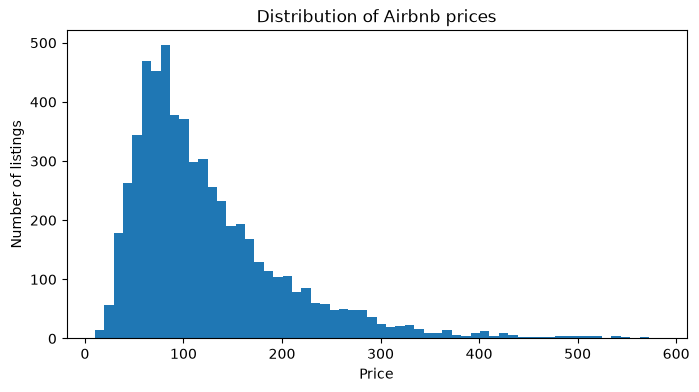

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(train["price"], bins=60)
plt.xlabel("Price")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb prices")
plt.show()

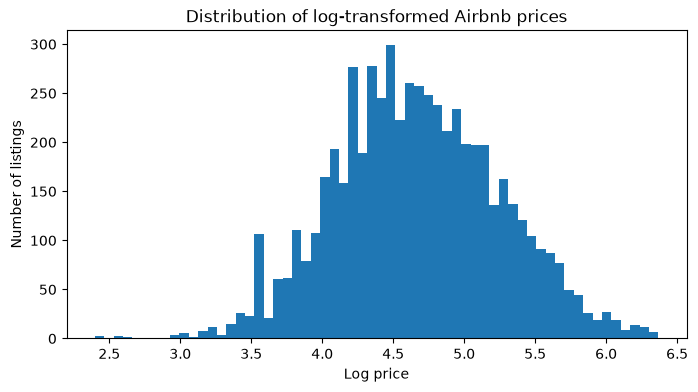

In [12]:
if "log_price" in train.columns:
    plt.figure(figsize=(8, 4))
    plt.hist(train["log_price"], bins=60)
    plt.xlabel("Log price")
    plt.ylabel("Number of listings")
    plt.title("Distribution of log-transformed Airbnb prices")
    plt.show()

In [15]:
possible_leakage_keywords = [
    "price",
    "revenue",
    "occupancy",
    "target",
    "estimated"
]

possible_leakage_columns = [
    col
    for col in train.columns
    if any(keyword in col.lower() for keyword in possible_leakage_keywords)
]

possible_leakage_columns

['price', 'log_price']

In [16]:
missing_summary = (
    train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percent")
)

display(missing_summary.head(20))

,missing_percent
neighborhood_overview,55.453306
host_about,45.040900
description,3.749148
listing_id,0.000000
name,0.000000
host_id,0.000000
host_response_rate,0.000000
host_acceptance_rate,0.000000
is_superhost,0.000000
host_listings_count,0.000000


In [17]:
dtype_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_percent": train.isna().mean() * 100,
    "n_unique": train.nunique(dropna=False)
})

display(dtype_summary)

,dtype,missing_percent,n_unique
listing_id,int64,0.000000,5868
name,str,0.000000,5651
description,str,3.749148,4966
neighborhood_overview,str,55.453306,1929
host_id,int64,0.000000,3635
host_about,str,45.040900,1768
host_response_rate,float64,0.000000,57
host_acceptance_rate,float64,0.000000,98
is_superhost,int64,0.000000,2
host_listings_count,int64,0.000000,60


In [1]:
from pathlib import Path

import pandas as pd


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_READY_DIR = (
    PROJECT_ROOT
    / "data"
    / "model_ready"
)

train_full = pd.read_csv(
    MODEL_READY_DIR / "train_full.csv",
    low_memory=False
)

val_full = pd.read_csv(
    MODEL_READY_DIR / "val_full.csv",
    low_memory=False
)

test_full = pd.read_csv(
    MODEL_READY_DIR / "test_full.csv",
    low_memory=False
)

print("Train:", train_full.shape)
print("Validation:", val_full.shape)
print("Test:", test_full.shape)

Train: (5868, 548)
Validation: (1483, 548)
Test: (1853, 548)


In [2]:
print(
    "Train and validation columns match:",
    train_full.columns.tolist()
    == val_full.columns.tolist()
)

print(
    "Train and test columns match:",
    train_full.columns.tolist()
    == test_full.columns.tolist()
)

Train and validation columns match: True
Train and test columns match: True


In [3]:
for split_name, df in {
    "train": train_full,
    "val": val_full,
    "test": test_full
}.items():
    print(split_name)
    print(
        "Duplicate listing IDs:",
        df["listing_id"].duplicated().sum()
    )
    print(
        "Missing listing IDs:",
        df["listing_id"].isna().sum()
    )
    print()

train
Duplicate listing IDs: 0
Missing listing IDs: 0

val
Duplicate listing IDs: 0
Missing listing IDs: 0

test
Duplicate listing IDs: 0
Missing listing IDs: 0



In [4]:
tfidf_columns = [
    col
    for col in train_full.columns
    if col.startswith("tfidf_")
]

print("Number of TF-IDF columns:", len(tfidf_columns))

print(
    "Missing TF-IDF values in train:",
    train_full[tfidf_columns]
    .isna()
    .sum()
    .sum()
)

Number of TF-IDF columns: 500
Missing TF-IDF values in train: 0


In [5]:
sentiment_columns = [
    "review_sentiment_mean",
    "review_sentiment_median",
    "review_sentiment_std",
    "review_count",
    "negative_review_share",
    "positive_review_share",
    "has_reviews"
]

existing_sentiment_columns = [
    col
    for col in sentiment_columns
    if col in train_full.columns
]

train_full[
    existing_sentiment_columns
].describe()

,review_sentiment_mean,review_sentiment_median,review_sentiment_std,review_count,negative_review_share,positive_review_share,has_reviews
count,5868.000000,5868.000000,5868.000000,5868.000000,5868.000000,5868.000000,5868.000000
mean,0.261691,0.358511,0.423386,59.594751,0.154438,0.467095,0.780164
std,0.311409,0.417388,0.296374,122.987678,0.174505,0.320366,0.414171
min,-0.987700,-0.987700,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,0.258583,0.350600,0.547627,14.000000,0.127660,0.534759,1.000000
75%,0.470795,0.770800,0.641291,66.000000,0.235294,0.699364,1.000000
max,0.996250,0.996250,1.370585,2895.000000,1.000000,1.000000,1.000000


In [6]:
print(
    "Mean sentiment valid:",
    train_full["review_sentiment_mean"]
    .between(-1, 1)
    .all()
)

print(
    "Positive share valid:",
    train_full["positive_review_share"]
    .between(0, 1)
    .all()
)

print(
    "Negative share valid:",
    train_full["negative_review_share"]
    .between(0, 1)
    .all()
)

print(
    "Review count valid:",
    (train_full["review_count"] >= 0).all()
)

print(
    "has_reviews values:",
    sorted(train_full["has_reviews"].unique())
)

Mean sentiment valid: True
Positive share valid: True
Negative share valid: True
Review count valid: True
has_reviews values: [np.int64(0), np.int64(1)]
